## Required Libraries

In [43]:
import numpy as np
import matplotlib.pyplot as plt

## System Parameters

In [44]:
np.random.seed(42)

N_UE = 3                     # Number of User Equipments
N_EDGE = 2                   # Number of Edge Servers
N_TIME_SLOT = 200            # Number of time slots
DURATION_S = 1.0             # Duration of one time slot in seconds

UE_COMP_CAP = 2.6            # Local CPU (GHz)
UE_COMP_POWER = 1.5          # Local computation power (W)
UE_TX_POWER = 3.5            # Transmission power (W)
UE_TX_RATE = 14.0            # Transmission Rate (Mbps)

EDGE_COMP_CAP = 41.8         # Edge Server CPU (GHz)

TASK_COMP_DENS = 0.397       # Task Density (Gcycles/Mbits)
TASK_MIN_SIZE = 1.0          # Mbits
TASK_MAX_SIZE = 7.0          # Mbits

## System Environment

In [45]:
class Environment:
    def __init__(self, n_ue, n_edge, n_time_slot, duration):
        self.n_ue = n_ue
        self.n_edge = n_edge
        self.n_time = n_time_slot
        self.duration = duration
        self.time_count = 0
        
        self.backlog_ue = np.zeros(n_ue)
        self.backlog_edge = np.zeros(n_edge)
        
        self.history = []

    def reset(self):
        self.time_count = 0
        self.backlog_ue.fill(0.0)
        self.backlog_edge.fill(0.0)
        self.history = []
        return self.get_states()

    def get_states(self, task_sizes=None):
        """
        State for each UE: [Task Size, Local Backlog, Server 1 Backlog, Server 2 Backlog]
        """
        if task_sizes is None:
            task_sizes = np.zeros(self.n_ue)
            
        states = []
        for i in range(self.n_ue):
            s = [task_sizes[i], self.backlog_ue[i], self.backlog_edge[0], self.backlog_edge[1]]
            states.append(s)
        return states

    def step(self, actions, task_sizes):
        """
        actions: list of ints [0, 1, 2] for each UE
        task_sizes: list of floats (Mbits) for current slot
        """
        self.backlog_ue = np.maximum(0, self.backlog_ue - self.duration)
        self.backlog_edge = np.maximum(0, self.backlog_edge - self.duration)
        
        total_delay_slot = 0
        total_energy_slot = 0
        
        for i in range(self.n_ue):
            action = actions[i]
            size_mb = task_sizes[i]
            load_gc = size_mb * TASK_COMP_DENS
            
            delay = 0
            energy = 0
            
            if action == 0: # LOCAL
                proc_time = load_gc / UE_COMP_CAP
                
                # Delay = Local Wait + Local Proc
                delay = self.backlog_ue[i] + proc_time
                energy = proc_time * UE_COMP_POWER
                
                self.backlog_ue[i] += proc_time
                
            else: # OFFLOAD (Action 1 or 2)
                server_idx = action - 1
                
                tx_time = size_mb / UE_TX_RATE
                edge_proc_time = load_gc / EDGE_COMP_CAP
                
                # Delay = Transmission + Server Wait + Server Proc
                delay = tx_time + self.backlog_edge[server_idx] + edge_proc_time
                energy = tx_time * UE_TX_POWER
                
                self.backlog_edge[server_idx] += edge_proc_time

            total_delay_slot += delay
            total_energy_slot += energy
        
        self.time_count += 1
        done = self.time_count >= self.n_time
        
        self.history.append([total_delay_slot, total_energy_slot])
        
        return self.get_states(task_sizes), total_delay_slot, total_energy_slot, done

## Baselines

In [46]:
class RandomAgent:
    def get_action(self, state):
        return np.random.choice([0, 1, 2])

class LocalOnlyAgent:
    def get_action(self, state):
        return 0

## Task: Fuzzy Logic Controller

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

class FuzzyAgent:
    def __init__(self):
        """
        You must implement a Mamdani-type fuzzy controller that decides:
            0 = local execution
            1 = offload to server 1
            2 = offload to server 2

        INPUTS (provided by environment):
            task_size      : [0, 7]
            local_queue    : [0, 3]
            edge_queue     : [0, 1]   (min of the two server queues)

        OUTPUT:
            offload_pref   : [0, 100]
                <= 50  → choose local
                >  50 → offload to least-loaded server

        Your tasks:
            - Define fuzzy antecedents and their membership functions
            - Define the fuzzy consequent and its membership functions
            - Design a meaningful rule base
            - Create a ControlSystem and ControlSystemSimulation
        """

        # =====================================
        # TODO 1 — Define fuzzy input variables
        # =====================================
        task_size = ctrl.Antecedent(np.arange(0, 7.1, 0.1), 'task_size')
        local_queue = ctrl.Antecedent(np.arange(0, 3.1, 0.1), 'local_queue')
        edge_queue = ctrl.Antecedent(np.arange(0, 1.1, 0.05), 'edge_queue')

        # =====================================
        # TODO 2 — Define fuzzy output variable
        # =====================================
        offload_pref = ctrl.Consequent(np.arange(0, 101, 1), 'offload_pref')

        # =====================================
        # TODO 3 — Define membership functions
        # (All sets for all variables must be added by students)
        # =====================================
       # Task Size membership functions (Small / Medium / Large)  [more conservative]
        task_size['small']  = fuzz.trimf(task_size.universe, [0, 0, 3.0])
        task_size['medium'] = fuzz.trimf(task_size.universe, [2.0, 4.0, 6.0])
        task_size['large']  = fuzz.trimf(task_size.universe, [5.2, 7.0, 7.0])

        # Local Queue membership functions (Low / Medium / High)   [shift high earlier]
        local_queue['low']    = fuzz.trimf(local_queue.universe, [0, 0, 1.0])
        local_queue['medium'] = fuzz.trimf(local_queue.universe, [0.7, 1.5, 2.3])
        local_queue['high']   = fuzz.trimf(local_queue.universe, [1.7, 3.0, 3.0])

        # Edge Queue membership functions (Low / Medium / High)    [detect congestion earlier]
        edge_queue['low']    = fuzz.trimf(edge_queue.universe, [0, 0, 0.35])
        edge_queue['medium'] = fuzz.trimf(edge_queue.universe, [0.25, 0.5, 0.75])
        edge_queue['high']   = fuzz.trimf(edge_queue.universe, [0.55, 1.0, 1.0])

        # Offload Preference membership functions (Local / Neutral / Offload)
        offload_pref['local']   = fuzz.trimf(offload_pref.universe, [0, 0, 55])
        offload_pref['neutral'] = fuzz.trimf(offload_pref.universe, [35, 55, 75])
        offload_pref['offload'] = fuzz.trimf(offload_pref.universe, [65, 100, 100])

        # =====================================
        # TODO 4 — Define fuzzy rules
        # (Use your own rule base, consistent with your membership functions)
        # =====================================
        # Example:
        rules=[]
        rules.append(ctrl.Rule(edge_queue['high'], offload_pref['local']))

        # If task is large and edge not high → offload
        rules.append(ctrl.Rule(task_size['large'] & edge_queue['low'], offload_pref['offload']))
        rules.append(ctrl.Rule(task_size['large'] & edge_queue['medium'], offload_pref['offload']))

        #  If local queue is high and edge is low/medium → offload
        rules.append(ctrl.Rule(local_queue['high'] & edge_queue['low'], offload_pref['offload']))
        rules.append(ctrl.Rule(local_queue['high'] & edge_queue['medium'], offload_pref['offload']))

        # If task is small and local queue low → local
        rules.append(ctrl.Rule(task_size['small'] & local_queue['low'], offload_pref['local']))

        # If task is medium and local is medium → neutral
        rules.append(ctrl.Rule(task_size['medium'] & local_queue['medium'] & edge_queue['medium'], offload_pref['neutral']))

        # If local is medium/high but edge is low → more offload
        rules.append(ctrl.Rule(local_queue['medium'] & edge_queue['low'], offload_pref['offload']))

        # If task medium + edge high → local
        rules.append(ctrl.Rule(task_size['medium'] & edge_queue['high'], offload_pref['local']))

        # Default balancing
        rules.append(ctrl.Rule(task_size['medium'] & local_queue['low'] & edge_queue['low'], offload_pref['neutral']))
        rules.append(ctrl.Rule(task_size['small'] & local_queue['high'] & edge_queue['low'], offload_pref['offload']))

        # Build control system
        self.offload_ctrl = ctrl.ControlSystem(rules)


        # Build simulation interface
        self.simulation = ctrl.ControlSystemSimulation(self.offload_ctrl)

    def get_action(self, state):
        """
        Input state = [task_size, local_queue, server1_queue, server2_queue]
        Output action = {0, 1, 2}
        """

        t_size, lq, s1q, s2q = state
        best_edge_queue = min(s1q, s2q)

        # Fuzzify inputs
        self.simulation.input['task_size'] = np.clip(t_size, 0, 7)
        self.simulation.input['local_queue'] = np.clip(lq, 0, 3)
        self.simulation.input['edge_queue'] = np.clip(best_edge_queue, 0, 1)

        try:
            self.simulation.compute()
            score = self.simulation.output['offload_pref']
        except:
            # If the student controller is incomplete or inconsistent,
            # default to a neutral decision.
            score = 50

        # Convert fuzzy score to discrete action
        if score > 50:
            return 1 if s1q <= s2q else 2
        else:
            return 0

## Simulation

In [48]:
def run_simulation(agent_factory, n_ue=N_UE, n_edge=N_EDGE, n_time=N_TIME_SLOT):
    all_tasks = np.random.uniform(TASK_MIN_SIZE, TASK_MAX_SIZE, (n_time, n_ue))
    
    env = Environment(n_ue, n_edge, n_time, DURATION_S)
    env.reset()
    
    agents = [agent_factory() for _ in range(n_ue)]
    
    done, t_idx = False, 0
    while not done:
        current_tasks = all_tasks[t_idx]
        
        # 1. Get States
        states = env.get_states(current_tasks)
        
        # 2. Get Actions from Agents
        actions = [agents[i].get_action(states[i]) for i in range(n_ue)]
        
        # 3. Step Environment
        _, _, _, done = env.step(actions, current_tasks)
        t_idx += 1

    history = np.array(env.history)
    total_delay = np.sum(history[:, 0])
    total_energy = np.sum(history[:, 1])
    
    # Cost function for comparison
    # A simple balanced cost: Delay + Energy
    weighted_cost = total_delay + total_energy
    
    return weighted_cost, total_delay, total_energy

## Evaluation

Agent                     | Cost       | Delay      | Energy    
-----------------------------------------------------------------
Local Only                | 922.2      | 370.1      | 552.2     
Random                    | 834.2      | 255.1      | 579.1     
Fuzzy Logic               | 810.7      | 229.8      | 581.0     


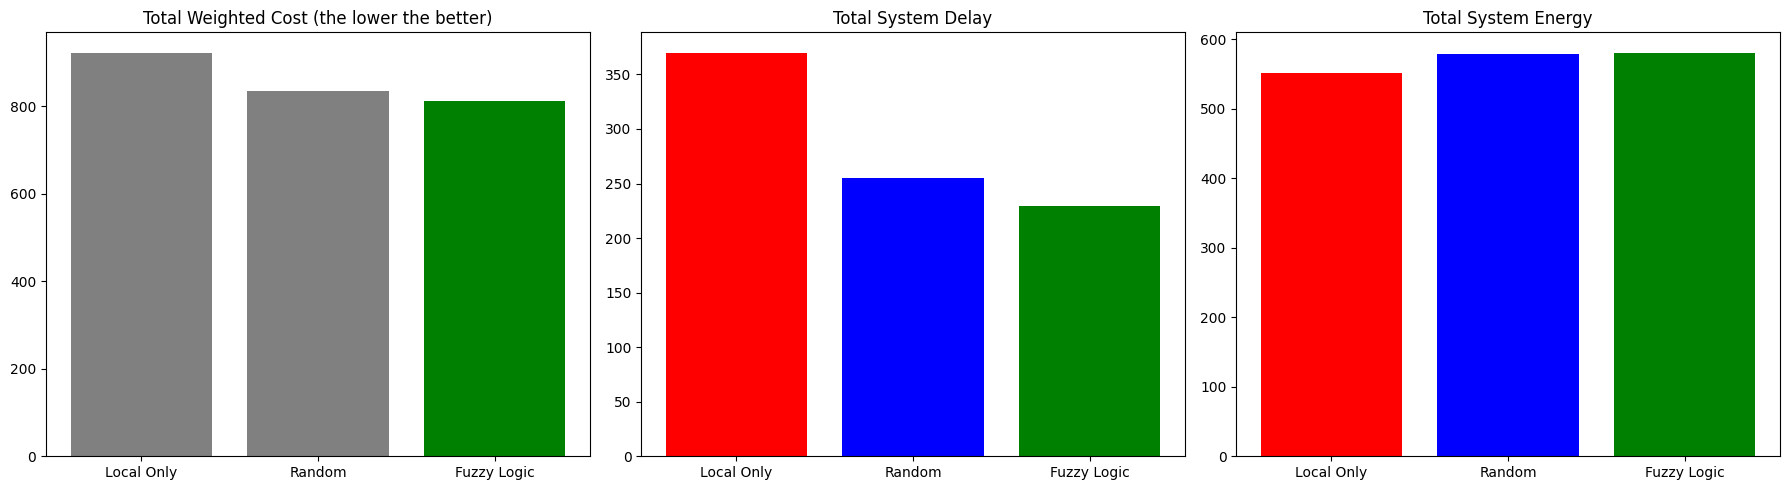

In [49]:
agents = {
    "Local Only": LocalOnlyAgent,
    "Random": RandomAgent,
    "Fuzzy Logic": FuzzyAgent 
}

print(f"{'Agent':<25} | {'Cost':<10} | {'Delay':<10} | {'Energy':<10}")
print("-" * 65)

results_cost = {}
results_delay = {}
results_energy = {}

for name, agent_cls in agents.items():
    cost, d, e = run_simulation(agent_cls)
    
    results_cost[name] = cost
    results_delay[name] = d
    results_energy[name] = e
    
    print(f"{name:<25} | {cost:<10.1f} | {d:<10.1f} | {e:<10.1f}")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].bar(results_cost.keys(), results_cost.values(), color=['gray', 'gray', 'green'])
ax[0].set_title("Total Weighted Cost (the lower the better)")

ax[1].bar(results_delay.keys(), results_delay.values(), color=['red', 'blue', 'green'])
ax[1].set_title("Total System Delay")

ax[2].bar(results_energy.keys(), results_energy.values(), color=['red', 'blue', 'green'])
ax[2].set_title("Total System Energy")

plt.tight_layout()
plt.show()

<div dir = "rtl">
1) Why Fuzzy Logic?
. در مسئله‌ی Computation Offloading نیز دستگاه (UE) باید تصمیم بگیرد که یک کار را محلی اجرا کند یا آن را به یکی از سرورهای edge ارسال کند؛ در حالی که وضعیت صف محلی، صف سرورهای edge و اندازه‌ی کار همگی متغیر و غیرقطعی‌اند.

روش‌های کلاسیک (مانند تصمیم‌گیری سخت آستانه‌ای یا کنترل دودویی) معمولاً انعطاف‌پذیری کافی برای مواجهه با این نوع عدم قطعیت را ندارند و ممکن است باعث تصمیم‌های ناپایدار یا غیر بهینه شوند.
منطق فازی یک راهکار مناسب ارائه می‌دهد زیرا:

مدیریت عدم قطعیت: مفاهیمی مانند “کار کوچک”، “صف زیاد” یا “سرور شلوغ” را به صورت طبیعی مدل می‌کند.

قابل تفسیر بودن: تصمیم نهایی حاصل مجموعه‌ای از قوانین IF–THEN است و می‌توان دقیقاً روند تصمیم‌گیری را توضیح داد.

غیرخطی و انعطاف‌پذیر: بدون نیاز به مدل‌های سنگین یادگیری عمیق، می‌تواند رفتارهای غیرخطی پیچیده را تقریب بزند.

بنابراین، استفاده از یک Fuzzy Logic Controller (Mamdani-type) باعث می‌شود تصمیم‌گیری offloading نسبت به تغییرات ناگهانی شرایط شبکه و منابع مقاوم‌تر و پایدارتر باشد.


2) Core Concept: Computation Offloading

در هر time slot، هر UE دقیقاً یک task تولید می‌کند و باید بین سه اکشن یکی را انتخاب کند:

0 = اجرای محلی (Local Execution)

1 = Offload به Server 1

2 = Offload به Server 2

اجرای محلی باعث افزایش مصرف انرژی و تأخیر پردازشی می‌شود، مخصوصاً زمانی که صف محلی سنگین باشد.
Offloading می‌تواند تأخیر و انرژی UE را کاهش دهد، اما باعث ایجاد موارد زیر می‌شود:

تأخیر ارسال روی لینک بی‌سیم (Transmission Delay)

زمان انتظار در صف سرور (Queue Waiting)

تأخیر پردازش روی سرور (Processing Delay)

بنابراین هدف کنترل‌کننده این است که در هر زمان تصمیم بگیرد چه گزینه‌ای کمترین هزینه‌ی تجمعی را داشته باشد:

Weighted Cost=Total Delay+Total Energy


3) Inputs and Membership Functions

در این پیاده‌سازی سه ورودی برای سیستم فازی تعریف شده‌اند که طبق صورت سؤال باید دقیقاً از بازه‌های مشخص استفاده شود:

 Input 1 — Task Size (S) ∈ [0, 7]

سه مجموعه‌ی فازی برای اندازه‌ی task تعریف شد:

small

medium

large

Membership functionها به صورت مثلثی (trimf) طراحی شدند به شکلی که کارهای کوچک حساسیت بیشتری به تصمیم محلی داشته باشند و کارهای بزرگ معمولاً به سمت offloading سوق داده شوند.

 Input 2 — Local Queue (QLocal) ∈ [0, 3]

این ورودی نشان‌دهنده‌ی backlog پردازشی UE است. سه مجموعه‌ی فازی تعریف شد:

low

medium

high

در طراحی membership functionها، مجموعه‌ی high کمی زودتر فعال می‌شود تا در شلوغی محلی، offloading سریع‌تر انتخاب شود.

 Input 3 — Edge Queue (QEdge) ∈ [0, 1]

برای مدل کردن وضعیت سرورهای edge از ورودی زیر استفاده شد:


QEdge=min(QServer1,QServer2)

سه مجموعه‌ی فازی برای این ورودی نیز تعریف شد:

low

medium

high

در membership functionهای edge_queue، ناحیه‌ی congestion به صورت زودتر تشخیص داده می‌شود تا اگر سرورها شلوغ بودند، سیستم تصمیم به اجرای محلی بگیرد.


4) Output Variable: Offload Preference (POff)

خروجی سیستم فازی یک متغیر پیوسته به نام Offload Preference است:

Range: [0, 100]

سه مجموعه‌ی معنایی برای خروجی تعریف شده است:

local  تمایل به اجرای محلی

neutral  حالت میانی / تصمیم محتاطانه

offload  تمایل به offloading

این خروجی به صورت Mamdani-type و با defuzzification در محیط تبدیل به تصمیم نهایی می‌شود.



<div dir="rtl">

5) Rule Base Design (IF–THEN Rules)



قوانین فازی در این کنترل‌کننده با هدف ایجاد تعادل بین تاخیر اجرای محلی و هزینه‌ی Offloading طراحی شده‌اند. تصمیم نهایی بر اساس سه ورودی انجام می‌شود: اندازه‌ی تسک (Task Size)، صف محلی (Local Queue) و صف Edge (Edge Queue). منطق کلی قوانین به این صورت است که:

تسک‌های بزرگ معمولاً برای Offloading مناسب‌تر هستند، چون اجرای محلی آن‌ها هم زمان‌بر است و هم انرژی بیشتری مصرف می‌کند.

اگر صف محلی زیاد باشد، اجرای محلی باعث افزایش تاخیر می‌شود، بنابراین Offloading ترجیح داده می‌شود (به شرطی که Edge شلوغ نباشد).

اگر صف Edge زیاد باشد، Offloading باعث انتظار طولانی در صف سرور می‌شود، بنابراین حتی برای تسک‌های بزرگ نیز ممکن است اجرای محلی به‌صرفه‌تر باشد.

در شرایط مرزی یا متوسط، خروجی «neutral» استفاده می‌شود تا تصمیم سیستم پایدارتر شود و از تغییرات ناگهانی و نوسانی جلوگیری شود.

 گروه‌بندی منطق قوانین

A) قوانین محدودکننده‌ی Edge (Edge Congestion Dominant)  (rule 1,9)

اگر QEdge بالا باشد، Offloading معمولاً نامطلوب است، چون زمان انتظار در صف سرور زیاد می‌شود. بنابراین در این شرایط، کنترل‌کننده تمایل بیشتری به اجرای محلی نشان می‌دهد، حتی اگر اندازه‌ی task متوسط یا بزرگ باشد.
هدف این قوانین جلوگیری از Offloading بی‌فایده در زمان congestion است.


B) قوانین مناسب برای Offloading (Large/Heavy Task + Edge Available) (rule 2,3)

اگر task بزرگ باشد و در عین حال QEdge کم یا متوسط باشد، Offloading بهترین گزینه است، چون:
زمان اجرای محلی زیاد می‌شود
Offloading هم انرژی UE را کاهش می‌دهد
و هم latency کلی کمتر خواهد بود چون سرور در دسترس است
این قوانین باعث می‌شوند سیستم برای taskهای سنگین در شرایط مناسب edge، تصمیم offload بگیرد.


C) قوانین مربوط به شلوغی محلی (Local Congestion) (rule 4,5,8)

اگر صف محلی بالا باشد، اجرای محلی باعث تجمع backlog و افزایش زمان اجرای taskها می‌شود.
در نتیجه در شرایطی که QLocal بالا و QEdge غیرشلوغ باشد، Offloading حتی برای taskهای متوسط نیز ترجیح داده می‌شود.
این بخش از قوانین به نوعی نقش “load shedding” از روی UE را انجام می‌دهد.


D) قوانین اجرای محلی برای taskهای سبک (Lightweight Local Case) (rule 6)

اگر task کوچک باشد و QLocal پایین یا متوسط باشد، اجرای محلی معمولاً به‌صرفه‌تر است زیرا:
زمان اجرای محلی کوتاه است
و Offloading فقط overhead شبکه و ارسال را اضافه می‌کند
بنابراین کنترل‌کننده در این وضعیت‌ها خروجی نزدیک به local تولید می‌کند.


E) قوانین Neutral برای کاهش نوسان تصمیم (Conflict / Borderline Handling) (rule 7,10)

در برخی شرایط، ورودی‌ها پیام‌های متضاد دارند (مثلاً task متوسط است ولی هم صف محلی هم صف edge در حد متوسط‌اند). در این حالت، سیستم به جای تصمیم‌گیری شدید، خروجی neutral می‌دهد تا رفتار کنترل‌کننده پایدارتر و منطقی‌تر باشد.
این باعث می‌شود سیستم در شرایط مرزی بین local و offload نوسان زیاد نداشته باشد.


چند مثال کوچک از تصمیم‌گیری

Task بزرگ + Edge خلوت → Offload
چون اجرای محلی سنگین است و Edge ظرفیت کافی دارد.

Task کوچک + Local Queue کم → Local
چون هزینه‌ی ارسال و delay شبکه ارزش Offloading ندارد.

Local Queue بالا + Edge متوسط → Offload
چون صف محلی باعث افزایش شدید latency می‌شود و edge هنوز قابل استفاده است.

Edge Queue بالا (congested) → Local
چون Offloading باعث انتظار طولانی در صف server می‌شود.

<div dir='rtl'>

6) Action Selection Logic

محیط شبیه‌ساز طبق صورت سؤال خروجی را به action تبدیل می‌کند:

اگر 
POff≤50 → Action 0 (Local Execution)

اگر 
POff>50 → Offload به سروری که صفش کمتر است:

اگر 
QServer1≤QServer2 → Action 1

اگر 
QServer1>QServer2 → Action 2

بنابراین کنترل‌کننده فقط مقدار preference را تعیین می‌کند و انتخاب بین server1 و server2 به صورت خودکار انجام می‌شود.

7) Integration and Simulation

کلاس FuzzyAgent در حلقه‌ی شبیه‌سازی قرار داده شد و سیستم برای:

200 time slots

برای چند UE

با دو edge server

اجرا شد.
محیط به طور خودکار نتایج را محاسبه می‌کند:

Total Delay

Total Energy

Total Weighted Cost = Delay + Energy

8) Baseline Comparison

برای ارزیابی عملکرد، نتایج Fuzzy Logic Controller با دو baseline مقایسه شدند:

Local Only → همه‌ی کارها محلی اجرا می‌شوند.

Random → اکشن‌ها به صورت تصادفی از {0,1,2} انتخاب می‌شوند.

Fuzzy Logic → کنترل‌کننده طراحی شده با قوانین فازی

 هدف بيان شده توسط سوال اين است که
FuzzyAgent باید Total Weighted Cost کمتری از هر دو baseline داشته باشد، که با طراحی قوانین و membership functionها تلاش شد این هدف محقق شود.

9) Performance Plots

در نهایت برای مقایسه‌ی عملکرد سه روش، نمودارهای میله‌ای (bar chart) رسم شد که شامل مقایسه‌ی موارد زیر است:

Total Cost

Total Delay

Total Energy

این نمودارها به صورت خلاصه نشان می‌دهند که Fuzzy Logic چگونه بین تأخیر و انرژی تعادل ایجاد کرده و منجر به هزینه‌ی کلی کمتر نسبت به baselineها شده است.

مدل فازي ما delay خيلي کمتري نسبت به دو مدل ديگر داشت اما enrgy آن کمي بالا بود و مجموع اين دو که مقدار cost را ميدهد از هر دو مدل ديگر کمتر بود.

</div>

Agent                     | Cost       | Delay      | Energy    
-----------------------------------------------------------------
Local Only                | 922.2      | 370.1      | 552.2     
Random                    | 834.2      | 255.1      | 579.1     
Fuzzy Logic               | 810.7      | 229.8      | 581.0     


<div dir='rtl'>

در این مسئله معیار اصلی ارزیابی عملکرد Agent برابر است با:

Cost=Delay+Energy

یعنی هدف کنترل‌کننده فقط کم کردن انرژی نیست، بلکه باید مجموع تأخیر و انرژی را به حداقل برساند.
کنترل‌کننده‌ی فازی برای کاهش Cost، معمولاً تصمیم می‌گیرد در شرایط مناسب، وظایف را بیشتر offload کند تا تأخیر اجرای محلی کاهش پیدا کند.

اما offloading علاوه بر کاهش تأخیر، یک هزینه‌ی انرژی اضافه نیز دارد، زیرا هنگام ارسال task به سرور edge، دستگاه باید از طریق لینک بی‌سیم داده را ارسال کند و این کار باعث مصرف انرژی انتقال (Transmission Energy) می‌شود. بنابراین:

در حالت Local Only چون هیچ ارسال شبکه‌ای انجام نمی‌شود، انرژی کمتر است.

در حالت Random و مخصوصاً Fuzzy Logic چون offloading انجام می‌شود، انرژی بیشتری مصرف می‌شود.

در روش فازی این افزایش انرژی حتی منطقی‌تر هم هست، چون Agent معمولاً offloading را برای taskهای بزرگ یا زمانی که صف محلی زیاد است انتخاب می‌کند. این تصمیم باعث کاهش شدید Delay می‌شود، اما از آنجا که taskهای بزرگ داده‌ی بیشتری برای ارسال دارند، انرژی uplink نیز افزایش پیدا می‌کند.

در نتیجه، کنترل‌کننده‌ی فازی با پرداخت مقدار کمی انرژی بیشتر، موفق شده تأخیر را به شکل قابل توجهی کاهش دهد و در نهایت Cost کلی کاهش پیدا کرده است. به بیان دیگر، Agent انرژی را فدا کرده تا Delay کمتر شود، چون کاهش تأخیر در این محیط ارزش بیشتری در کاهش مجموع Cost دارد.


<div dir='rtl'>

 نتیجه‌گیری

در این پروژه یک کنترل‌کننده فازی از نوع Mamdani با استفاده از کتابخانه‌ی scikit-fuzzy پیاده‌سازی شد که با استفاده از ورودی‌های اندازه‌ی task، وضعیت صف محلی و وضعیت صف edge، تصمیم offloading را اتخاذ می‌کند.
طراحی قوانین به گونه‌ای انجام شده که:

از offloading برای taskهای بزرگ و صف محلی بالا استفاده شود،

اما در شرایط congestion edge، اجرای محلی ترجیح داده شود،

و با استفاده از خروجی neutral تصمیم‌ها پایدارتر شوند.

در نتیجه سیستم توانست نسبت به روش‌های baseline تصمیم‌گیری هوشمندانه‌تر و قابل تفسیرتری ارائه دهد.